## 1. Archive exploration

**a.**

(i) This dataset contains coded water conflict and crisis events in the Colorado River Basin, compiled by the U.S. Geological Survey (USGS). The data were derived from two sources: (1) a LexisNexis search of news articles and (2) observations of nine public, recorded meetings of water control boards and official organizations in the Basin. Discourse analysis was used to identify major themes, and events were coded for attributes including location, conflict presence, and crisis type.

(ii) **Time frame:** Observations span from January 2005 through December 2021.

(iii) **Perceived value:** The authors state the data were collected to catalogue and understand water-related conflicts in the Colorado River Basin. They note the dataset benefits the growing human-dimensions research that the USGS Water Mission Area is conducting, and may serve as background information for the series of water availability assessment reports USGS is producing.

**b.** 

## Data Description

This dataset contains coded water conflict and crisis events in the Colorado River Basin, compiled by the U.S. Geological Survey (USGS). Events were identified through a LexisNexis search of news articles and observations of nine public, recorded meetings of water control boards in the Basin. The data span January 2005 through December 2021.

The authors state the data were collected to catalogue and understand water-related conflicts in the region, supporting the USGS Water Mission Area's growing human-dimensions research and its series of water availability assessment reports. Since the dataset is derived from English-language news coverage, events absent from media reporting may be missing.

**Citation:** Holloman, D.V., Hines, M.K., and Zoanni, D.K., 2023, Coded Water Conflict and Crisis Events in the Colorado River Basin, Derived from LexisNexis search 2005-2021: U.S. Geological Survey data release, https://doi.org/10.5066/P9X6WR7J.

**Accessed:** October 8, 2026. [ScienceBase Repository](https://www.sciencebase.gov/catalog/item/63acac09d34e92aad3ca1480).

# 2. Data Loading

In [2]:
# Create data directory (terminal)
# mkdir data

# After downloading and uploading the CSV, update .gitignore (terminal)

# Verify git is ignoring the data file
    # git status and a check is that the CSV should NOT appear as an untracked file

# Load the data
import pandas as pd

df = pd.read_csv("data/Colorado River Basin Water Conflict Table.csv")

# 3. Preliminary Data Exploration

In [ ]:
# a. Display all columns
pd.set_option("display.max_columns", None)


In [14]:
# b. Explore Data in 4 ways:

# 1. Dimensions
# df.shape

# 2. Column names, dtypes, non-null counts
# df.info()

# 3. First few rows
# df.head()

# 4. Summary statistics (includes non-numeric columns with include='all')
# df.describe(include="all")

# 5. Missing values per column
# df.isna().sum()

# 6. Unique values per column
# df.nunique()

# 5. String accessor for pandas.Series

In [15]:
# CELL 1
import numpy as np
import pandas as pd 

# Example series
s = pd.Series(['California; Nevada', 'Arizona', np.nan, 'Nevada; Utah'])
s

0    California; Nevada
1               Arizona
2                   NaN
3          Nevada; Utah
dtype: object

In [16]:
# CELL 2
# str accessor (doesn't do anything by itself)
s.str

In [18]:
# CELL 3
# Use str accessor with additional methods to perform string operations
s.str.split(';')

0    [California,  Nevada]
1                [Arizona]
2                      NaN
3          [Nevada,  Utah]
dtype: object

In [17]:
# CELL 4
s.str.split(';').explode()

0    California
0        Nevada
1       Arizona
2           NaN
3        Nevada
3          Utah
dtype: object

# 6. Examine State Codes

In [ ]:
# a. Non-NA values in the State column
df.loc[df["State"].notna(), "State"]

b. Challenge: Some entries contain multiple states in a single cell separated by semicolons ("CA; NV"). Calling .unique() directly would treat "CA; NV" and "CA" as distinct values, so you'd get duplicated state codes embedded in compound strings rather than a clean list of individual states.

# 8. Exploratory Wrangling

In [19]:
# Step 1: Select State column where conflict is present
states_conflict = df.loc[df["Conflict Present"] == "Y", "State"]

# Step 2: Split on semicolon delimiter
states_split = states_conflict.str.split(";")

# Step 3: Explode lists into individual rows
states_exploded = states_split.explode()

# Step 4: Unique values, keeping NAs
states_unique = states_exploded.unique()
states_unique

array(['CO', nan, 'AZ', 'OH', ' UT', 'UT', 'CA', ' NV', ' WY', ' NM',
       ' CA', 'NV', ' AZ', ' CO', 'NM', 'WY'], dtype=object)

# 9. Find Unique State Codes

a. State codes appear duplicated because the original State column stores multi-state entries as semicolon-separated strings (e.g., "CA; NV"). When we split on ";", the delimiter is consumed but the surrounding whitespace is not — so the second element becomes " NV" rather than "NV". Since pandas compares strings character-by-character, " NV" != "NV", and .unique() returns both. To fix this, we need to strip leading and trailing whitespace from each element after splitting using str.strip().

In [21]:
# b. one method per line
states_unique = (
    df.loc[df["Conflict Present"] == "Y", "State"]
    .str.split(";")
    .explode()
    .str.strip()
    .unique()
)
states_unique

array(['CO', nan, 'AZ', 'OH', 'UT', 'CA', 'NV', 'WY', 'NM'], dtype=object)

# 10. Visualize data exploration & discussion

<Axes: title={'center': 'Water conflicts reported per state in the Colorado River Basin (2005–2021)'}, xlabel='State', ylabel='Number of conflicts'>

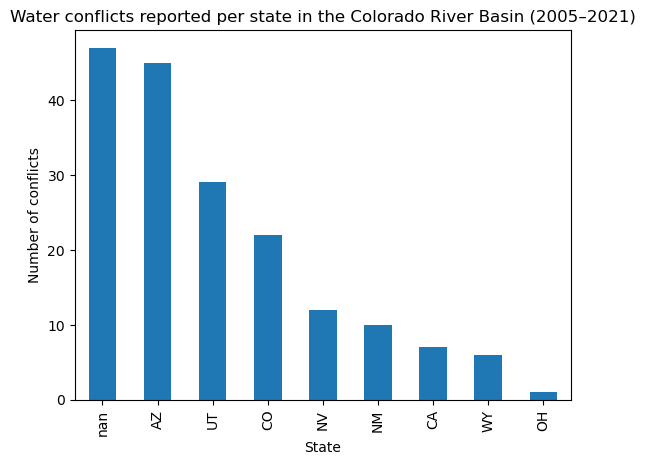

In [23]:
# a. Count conflicts per state, keeping NAs
state_counts = (
    df.loc[df["Conflict Present"] == "Y", "State"]
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts(dropna=False)
)

# Plot
state_counts.plot(
    kind="bar",
    xlabel="State",
    ylabel="Number of conflicts",
    title="Water conflicts reported per state in the Colorado River Basin (2005–2021)"
)

## b. Why might a state be missing?

Two types of missingness per the metadata:

(i) Empty cell → event was not coded (data collection gap)
(ii) NA → event was coded but no place referenced in the source text

Possible reasons:

(i) Article discussed Basin-wide policy without naming a specific state
(ii) Event not coded (resource constraints, deemed out of scope)
(iii) LexisNexis search terms failed to surface articles about conflicts in that state

## b. How does this affect what we can claim for our array of states?

Our array represents states mentioned in coded, conflict-present news articles captured by the search and not a complete inventory of states with water conflict in the Basin.

## c. Zoom out:

**Data issues found by looking closely:**

(i) Leading whitespace after `str.split(";")` created false duplicates (`"NV"` vs `" NV"`) — inflated unique counts and split bar plot bars
(ii) Pandas collapses empty cells and `NA` into a single `NaN`, hiding that they represent different types of missingness per the metadata

**Habitual checks for new datasets:**

(i) Run `value_counts(dropna=False)` on categorical columns before any analysis — surfaces hidden whitespace, unexpected values, encoding issues
(ii) Read the metadata/codebook first — missingness conventions and coding decisions are not self-evident from the data